# TabPFN-3 SCM Prior (Tabular Data)

The SCM prior from TabPFN-3 (Prior Labs Team, 2026, Section 2.5) generates
**tabular** datasets — a feature matrix $X \in \mathbb{R}^{N \times P}$ plus an
optional categorical target $y \in \{0, \dots, C-1\}^N$ — from a structural
causal model (SCM).

Each dataset is produced in five steps (Figure 9):

1. sample hyperparameters (rows / features / classes / graph type);
2. sample a DAG;
3. compute the SCM $X_v = f_v(\mathrm{pa}(X_v)) + \varepsilon_v$ row by row;
4. extract the feature matrix $X$ and discretize a target node into $C$ classes;
5. post-process (outliers, missing values, scale/shift).

Reference: Prior Labs Team (2026). *TabPFN-3: Technical Report*. arXiv:2605.13986.

In [1]:
import os
import sys

import numpy as np

sys.path.append(os.path.abspath(os.path.join("..", "..")))

from s2generator.scm import ScmPriorPipeline

Create a pipeline. By default it samples DAGs / combiners / activations
uniformly and applies post-processing; we disable post-processing here to keep the
data clean.

In [2]:
rng = np.random.RandomState(0)
pipe = ScmPriorPipeline(Vmin=6, Vmax=12, apply_postprocessing=False)

## Unsupervised tabular data (X only)

Without ``n_classes``, ``generate`` returns the feature matrix $X$ of shape $(N, P)$.

In [3]:
X = pipe.generate(rng, n_samples=200, n_features=4)
print("X shape:", X.shape)
print("X[:3]:\n", X[:3])

X shape: (200, 4)
X[:3]:
 [[-3.3593515   1.          0.46955063 -0.08171767]
 [ 0.86006399  1.          0.3075415   0.82968876]
 [ 1.13746832  1.          0.31109932 -0.91401073]]


## Supervised tabular data (X, y)

Passing ``n_classes`` adds a categorical target $y$ obtained by quantile-binning a
target node of the SCM. Classes are naturally balanced.

In [4]:
X, y = pipe.generate(rng, n_samples=200, n_features=4, n_classes=3)
print("X shape:", X.shape, " y shape:", y.shape)
print("class counts:", np.bincount(y))

X shape: (200, 4)  y shape: (200,)
class counts: [67 66 67]


## Custom DAG

A user-supplied adjacency matrix fixes the causal graph. Here we use a chain
$0 \to 1 \to \dots \to 5$; the features and the target are then read off from the
graph's nodes.

In [5]:
V = 6
adj = np.zeros((V, V), dtype=int)
for i in range(V - 1):
    adj[i, i + 1] = 1

X, y = pipe.generate(rng, n_samples=200, n_features=4, n_classes=3, adjacency=adj)
print("X shape:", X.shape, " y shape:", y.shape)

X shape: (200, 4)  y shape: (200,)


## Metadata

``return_metadata=True`` appends a dict describing the generated graph and dataset.

In [6]:
X, y, meta = pipe.generate(
    rng, n_samples=200, n_features=4, n_classes=3, return_metadata=True
)
print("metadata keys:", sorted(meta.keys()))
print(
    "n_nodes:",
    meta["n_nodes"],
    " n_edges:",
    meta["n_edges"],
    " n_classes:",
    meta["n_classes"],
)

metadata keys: ['categorical_features', 'edge_list', 'feature_nodes', 'graph_source', 'n_classes', 'n_edges', 'n_features', 'n_nodes', 'n_roots', 'n_rows', 'root_nodes', 'target_node']
n_nodes: 12  n_edges: 20  n_classes: 3


## Batch generation

``generate_batch`` produces a list of independent datasets.

In [7]:
batch = pipe.generate_batch(rng, n_batches=5, n_samples=128, n_features=3, n_classes=2)
print("n datasets:", len(batch))
print("first (X, y) shapes:", batch[0][0].shape, batch[0][1].shape)

n datasets: 5
first (X, y) shapes: (128, 3) (128,)


## Available components

The pipeline exposes the DAG algorithms, combiner mechanisms and activations it
samples from.

In [8]:
print("dag algorithms:", pipe.dag_algorithms)
print("combiner mechanisms:", pipe.combiner_mechanisms)
print("activations:", pipe.activations)

dag algorithms: ['chain', 'fork', 'collider', 'random', 'scale_free', 'bipartite']
combiner mechanisms: ['linear', 'mlp', 'polynomial', 'multiplicative', 'periodic', 'maxmin']
activations: ['relu', 'sigmoid', 'tanh', 'sin', 'gelu', 'softplus', 'identity', 'high_freq_sin']


## Visualize generated datasets

Tabular datasets have no time axis, so we treat each row as a step and draw each
feature as a line — one dataset per subplot.

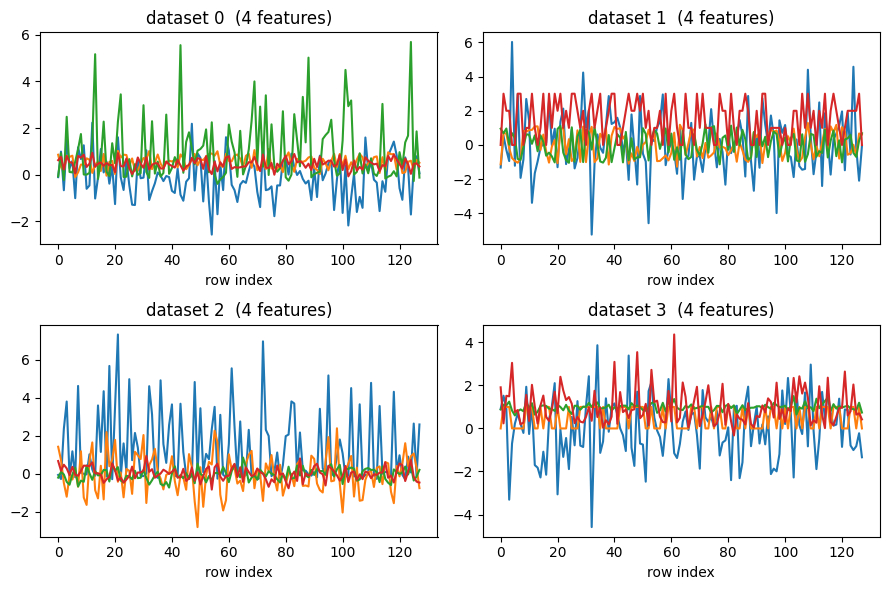

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

# Tabular data has no time axis; treat each row as a step and plot each feature
# as a line, one dataset per subplot.
rng = np.random.RandomState(0)
datasets = [pipe.generate(rng, n_samples=128, n_features=4) for _ in range(4)]

n = len(datasets)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)
for i, X in enumerate(datasets):
    ax = axes[i // ncols][i % ncols]
    ax.plot(X)  # (N, P): one line per feature
    ax.set_title(f"dataset {i}  ({X.shape[1]} features)")
    ax.set_xlabel("row index")
for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.tight_layout()
plt.show()